In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [2]:
conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()
print("Connected Successfully!")

Connected Successfully!


## User Engagement and Growth Strategy

## Scenario

PhonePe wants to understand user engagement across different
states and identify regions with high registered users.

The analysis focuses on user registration and engagement
patterns to support growth strategies.

## Objective

- Identify states with the highest registered users.
- Compare user engagement across states.
- Understand the distribution of registered users.
- Identify important regions for user growth.

### load data

In [3]:
query5="""
select top 10 *
from aggregated_user"""

df5=pd.read_sql(query5, conn)
df5

C:\Users\Devendra\AppData\Local\Temp\ipykernel_51120\770403553.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5=pd.read_sql(query5, conn)


,States,Years,Quarter,Brands,Transaction_count,Percentage
0,Andaman & Nicobar,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar,2018,1,OnePlus,332,0.049258
5,Andaman & Nicobar,2018,1,Realme,316,0.046884
6,Andaman & Nicobar,2018,1,Apple,229,0.033976
7,Andaman & Nicobar,2018,1,Motorola,226,0.033531
8,Andaman & Nicobar,2018,1,Lenovo,202,0.029970
9,Andaman & Nicobar,2018,1,Huawei,158,0.023442


# top states

In [6]:
query="""
select top 10
States,
sum(Transaction_count) as Total_Users
from aggregated_user
group by States
order by Total_Users desc"""

user_states= pd.read_sql(query, conn)
user_states

C:\Users\Devendra\AppData\Local\Temp\ipykernel_51120\754884019.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_states= pd.read_sql(query, conn)


,States,Total_Users
0,Maharashtra,904150022
1,Uttar Pradesh,711939266
2,Karnataka,582745560
3,Andhra Pradesh,450829670
4,Rajasthan,431291176
5,Telangana,423815506
6,West Bengal,412259550
7,Tamil Nadu,387330056
8,Gujarat,361462616
9,Madhya Pradesh,361324892


## bar chart

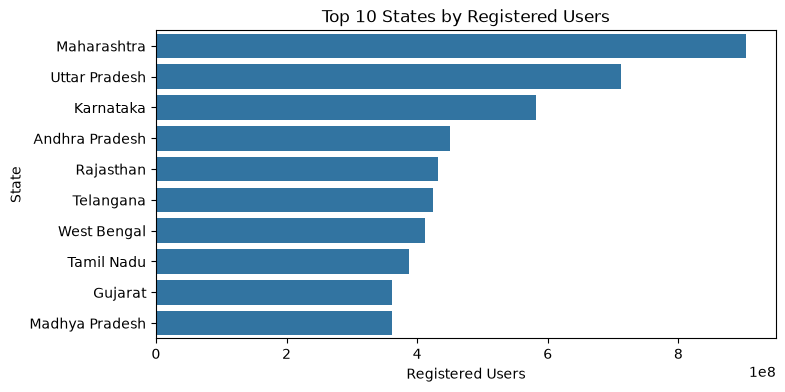

In [7]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=user_states,
    x="Total_Users",
    y="States")

plt.title("Top 10 States by Registered Users")
plt.xlabel("Registered Users")
plt.ylabel("State")

plt.show()

### User Distribution by Device Brand

In [8]:
query = """
SELECT
    Brands,
    SUM(Transaction_count) AS Total_Users
FROM aggregated_user
GROUP BY Brands
ORDER BY Total_Users DESC
"""

brand_users = pd.read_sql(query, conn)

brand_users

C:\Users\Devendra\AppData\Local\Temp\ipykernel_51120\1062665257.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  brand_users = pd.read_sql(query, conn)


,Brands,Total_Users
0,Xiaomi,1739125234
1,Samsung,1343207422
2,Vivo,1250830038
3,Oppo,840500490
4,Others,565900468
5,Realme,439946444
6,Apple,191894628
7,Motorola,146681468
8,OnePlus,127354422
9,Huawei,114259386


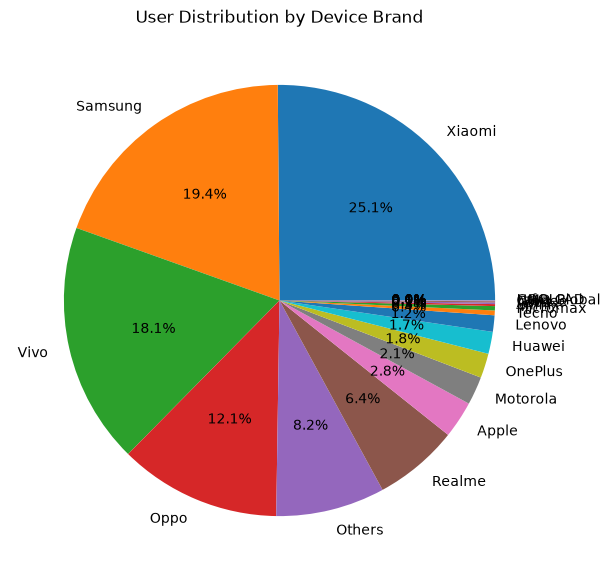

In [9]:
plt.figure(figsize=(7,7))

plt.pie(
    brand_users["Total_Users"],
    labels=brand_users["Brands"],
    autopct="%1.1f%%"
)

plt.title("User Distribution by Device Brand")

plt.show()

## Conclusion

The analysis identifies the states with the highest registered
user base and shows the distribution of users across device
brands.

These insights can help PhonePe focus user engagement campaigns
and growth strategies on important regions and device segments.